# June 5th Training Run Analysis: No-MADIS vs MADIS Full vs MADIS Top-3

First three-way comparison run with all overfitting fixes applied:
- Reduced MADIS branch: `Dense(32, relu) → Dense(16, relu)`, dropout 0.5, L2 regularization
- MLP head: `Dense(1024) → Dense(512)` with dropout 0.4 and L2
- Early stopping (patience=3) on all three runs
- All runs trained on 2013–2019, validated on 2020–2021, batch size 128
- MADIS top-3 features: pressure, wind_gust, pressure_anomaly_24h

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

no_madis  = pd.read_csv('../results/run_june_5th/results/no_madis_history.csv')
madis     = pd.read_csv('../results/run_june_5th/results/madis_history.csv')
madis_top3 = pd.read_csv('../results/run_june_5th/results/madis_top3_history.csv')

no_madis.index   = range(1, len(no_madis) + 1)
madis.index      = range(1, len(madis) + 1)
madis_top3.index = range(1, len(madis_top3) + 1)

print(f'No-MADIS epochs:   {len(no_madis)}')
print(f'MADIS full epochs: {len(madis)}')
print(f'MADIS top-3 epochs:{len(madis_top3)}')

best_no_madis_epoch   = no_madis['val_AUC'].idxmax()
best_madis_epoch      = madis['val_AUC'].idxmax()
best_madis_top3_epoch = madis_top3['val_AUC'].idxmax()

print(f'\nBest No-MADIS epoch:    {best_no_madis_epoch} — val_AUC={no_madis["val_AUC"].max():.4f}')
print(f'Best MADIS full epoch:  {best_madis_epoch} — val_AUC={madis["val_AUC"].max():.4f}')
print(f'Best MADIS top-3 epoch: {best_madis_top3_epoch} — val_AUC={madis_top3["val_AUC"].max():.4f}')

No-MADIS epochs:   9
MADIS full epochs: 9
MADIS top-3 epochs:9

Best No-MADIS epoch:    6 — val_AUC=0.8825
Best MADIS full epoch:  6 — val_AUC=0.8851
Best MADIS top-3 epoch: 6 — val_AUC=0.8822


## AUC Curves — All Three Runs

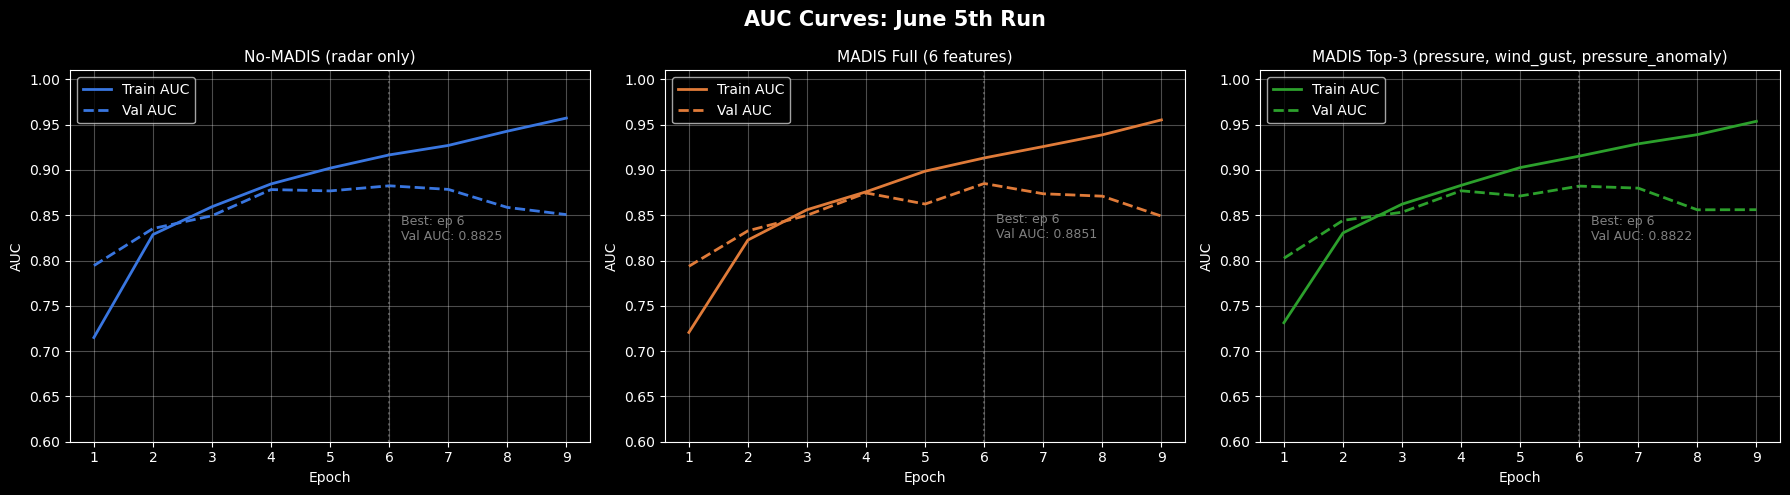

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

runs = [
    (no_madis,   'No-MADIS (radar only)',         '#3976e0'),
    (madis,      'MADIS Full (6 features)',        '#e07b39'),
    (madis_top3, 'MADIS Top-3 (pressure, wind_gust, pressure_anomaly)', '#2ca02c'),
]

for ax, (df, title, color) in zip(axes, runs):
    ax.plot(df.index, df['AUC'],     color=color, linewidth=2, label='Train AUC')
    ax.plot(df.index, df['val_AUC'], color=color, linewidth=2, linestyle='--', label='Val AUC')
    best_epoch = df['val_AUC'].idxmax()
    ax.axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6)
    ax.annotate(f'Best: ep {best_epoch}\nVal AUC: {df["val_AUC"].max():.4f}',
                xy=(best_epoch, df['val_AUC'].max()),
                xytext=(best_epoch + 0.2, df['val_AUC'].max() - 0.06),
                fontsize=9, color='gray')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_ylim(0.6, 1.01)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('AUC Curves: June 5th Run', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/june5_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Loss Curves

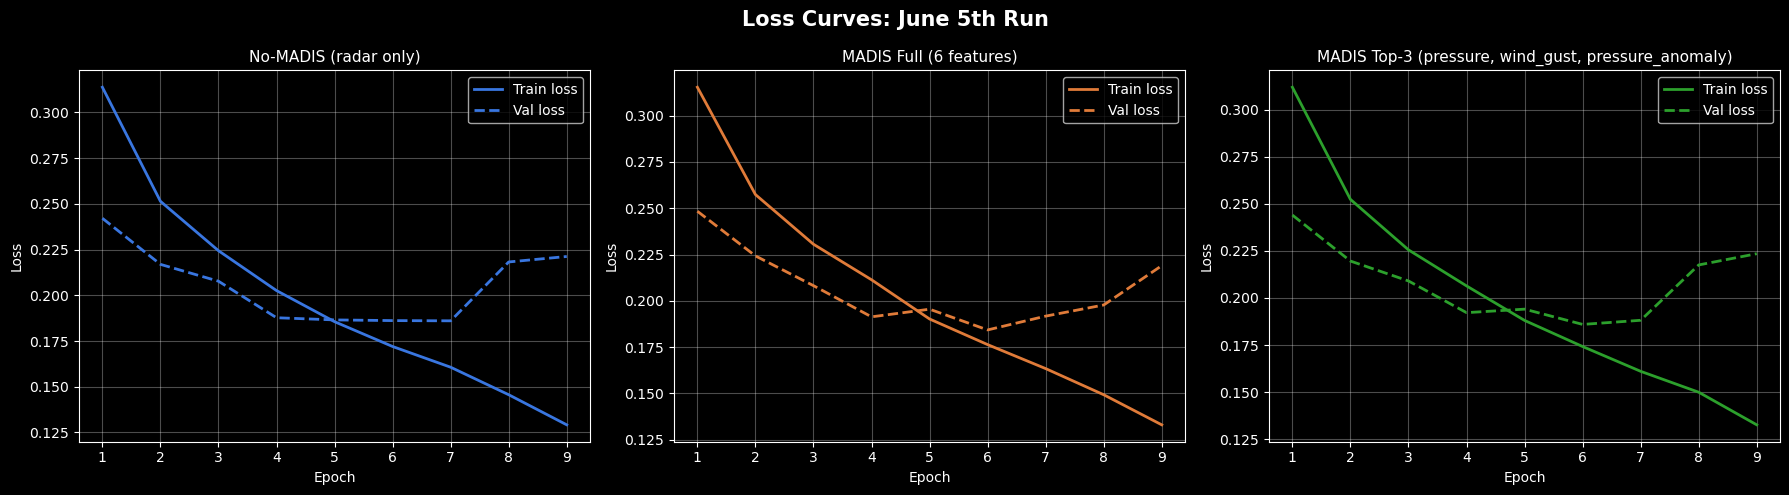

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, title, color) in zip(axes, runs):
    ax.plot(df.index, df['loss'],     color=color, linewidth=2, label='Train loss')
    ax.plot(df.index, df['val_loss'], color=color, linewidth=2, linestyle='--', label='Val loss')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Loss Curves: June 5th Run', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/june5_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Head-to-Head Val Metrics at Best Epoch

In [5]:
best_cols = ['val_AUC', 'val_AUCPR', 'val_F1', 'val_Precision', 'val_Recall', 'val_loss']

best_no_madis   = no_madis.loc[no_madis['val_AUC'].idxmax()]
best_madis      = madis.loc[madis['val_AUC'].idxmax()]
best_madis_top3 = madis_top3.loc[madis_top3['val_AUC'].idxmax()]

summary = pd.DataFrame({
    f'No-MADIS (ep {no_madis["val_AUC"].idxmax()})':    best_no_madis[best_cols],
    f'MADIS Full (ep {madis["val_AUC"].idxmax()})':     best_madis[best_cols],
    f'MADIS Top-3 (ep {madis_top3["val_AUC"].idxmax()})': best_madis_top3[best_cols],
})
print(summary.round(4))

               No-MADIS (ep 6)  MADIS Full (ep 6)  MADIS Top-3 (ep 6)
val_AUC                 0.8825             0.8851              0.8822
val_AUCPR               0.4834             0.4778              0.4892
val_F1                  0.4468             0.4721              0.4732
val_Precision           0.5808             0.4857              0.5155
val_Recall              0.3631             0.4593              0.4373
val_loss                0.1862             0.1843              0.1860


  No-MADIS is the most "trigger-shy" — its precision is highest (0.58) but it only catches 36% of actual tornadoes. For every tornado it detects, it misses nearly two.

  MADIS Full catches 27% more tornadoes than No-MADIS (recall 0.46 vs 0.36) while precision drops only ~10 points. In tornado detection terms, that's a meaningful safety improvement —
  missing a tornado costs lives; a false alarm costs an interrupted broadcast.

  The AUCPR flip is worth noting — No-MADIS (0.483) and Top-3 (0.489) both beat MADIS Full (0.478) on precision-recall area, which is the more important metric for rare-event detection
  like this. This means MADIS Full's higher recall at the default 0.5 threshold may be a threshold artifact — if you tuned the threshold, No-MADIS might reach similar recall with better
  precision.
  
  Bottom line: MADIS Full is producing a model that leans toward catching tornadoes rather than avoiding false alarms. Whether that's better depends on the use case, but for a warning
  system, that's arguably the right direction. The AUC scores are nearly identical (0.882–0.885), so all three models have similar overall discrimination power — the difference is just
  where they sit on the precision/recall curve at the default threshold.


## Val AUC Comparison Over Time

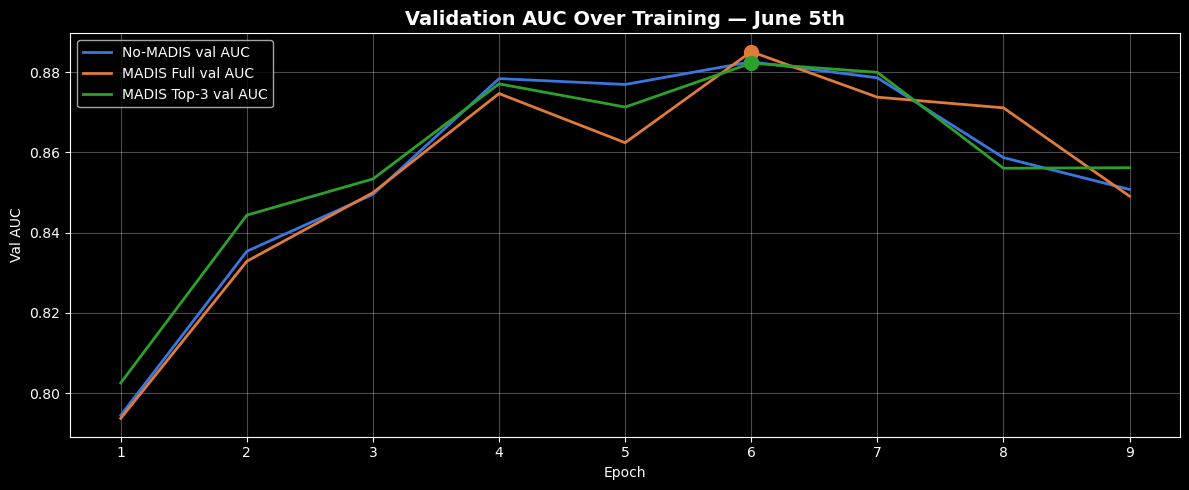

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for df, label, color in [
    (no_madis,   'No-MADIS val AUC',    '#3976e0'),
    (madis,      'MADIS Full val AUC',  '#e07b39'),
    (madis_top3, 'MADIS Top-3 val AUC', '#2ca02c'),
]:
    ax.plot(df.index, df['val_AUC'], color=color, linewidth=2, label=label)
    ax.scatter([df['val_AUC'].idxmax()], [df['val_AUC'].max()], color=color, s=100, zorder=5)

ax.set_title('Validation AUC Over Training — June 5th', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/june5_val_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Overfitting Gap

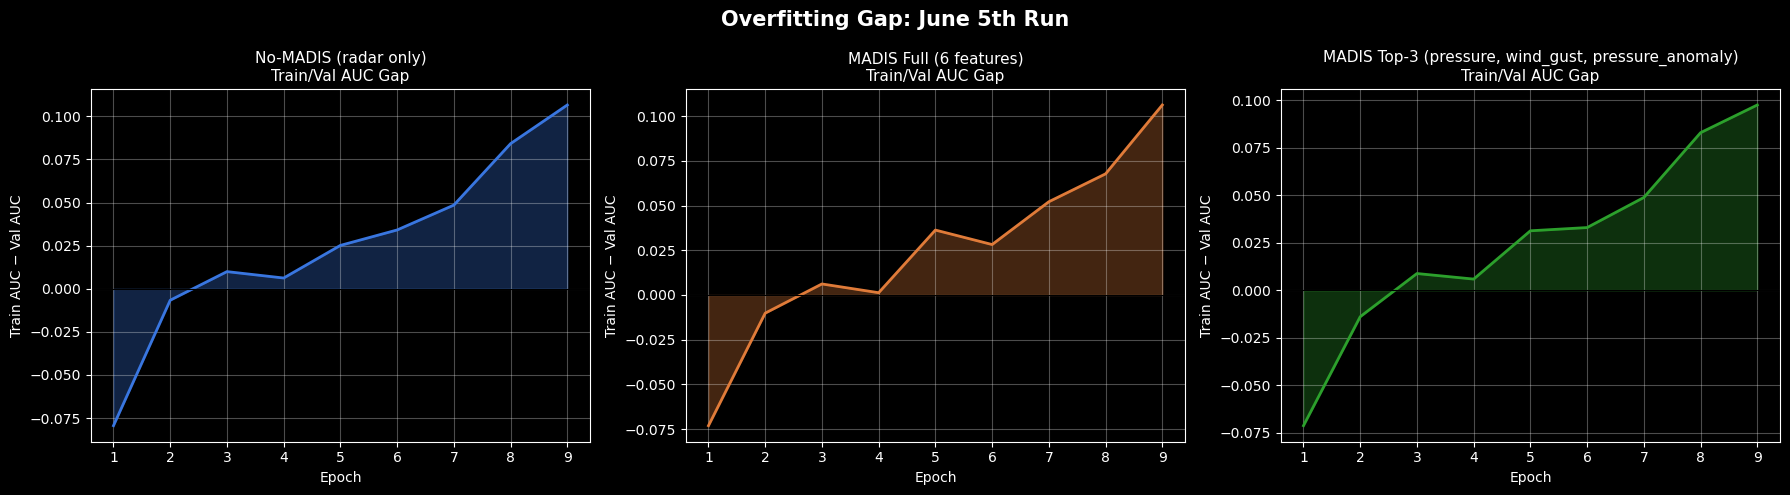

Final train/val AUC gap at last epoch:
  No-MADIS (ep 9):    0.1066
  MADIS Full (ep 9):  0.1062
  MADIS Top-3 (ep 9): 0.0976


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, title, color) in zip(axes, runs):
    gap = df['AUC'] - df['val_AUC']
    ax.fill_between(df.index, gap, alpha=0.3, color=color)
    ax.plot(df.index, gap, color=color, linewidth=2)
    ax.set_title(f'{title}\nTrain/Val AUC Gap', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train AUC − Val AUC')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Overfitting Gap: June 5th Run', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/june5_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Final train/val AUC gap at last epoch:')
print(f'  No-MADIS (ep {len(no_madis)}):    {no_madis["AUC"].iloc[-1] - no_madis["val_AUC"].iloc[-1]:.4f}')
print(f'  MADIS Full (ep {len(madis)}):  {madis["AUC"].iloc[-1] - madis["val_AUC"].iloc[-1]:.4f}')
print(f'  MADIS Top-3 (ep {len(madis_top3)}): {madis_top3["AUC"].iloc[-1] - madis_top3["val_AUC"].iloc[-1]:.4f}')

## Comparison with May 22nd Run

In [8]:
may22_madis    = pd.read_csv('../results/run_may_23rd/madis_history.csv')
may22_no_madis = pd.read_csv('../results/run_may_23rd/no_madis_history.csv')
may22_madis.index    = range(1, len(may22_madis) + 1)
may22_no_madis.index = range(1, len(may22_no_madis) + 1)

print('Best val_AUC comparison across runs:')
print(f'  May 22 No-MADIS:    {may22_no_madis["val_AUC"].max():.4f} (epoch {may22_no_madis["val_AUC"].idxmax()})')
print(f'  May 22 MADIS Full:  {may22_madis["val_AUC"].max():.4f} (epoch {may22_madis["val_AUC"].idxmax()})')
print()
print(f'  June 5 No-MADIS:    {no_madis["val_AUC"].max():.4f} (epoch {no_madis["val_AUC"].idxmax()})')
print(f'  June 5 MADIS Full:  {madis["val_AUC"].max():.4f} (epoch {madis["val_AUC"].idxmax()})')
print(f'  June 5 MADIS Top-3: {madis_top3["val_AUC"].max():.4f} (epoch {madis_top3["val_AUC"].idxmax()})')

Best val_AUC comparison across runs:
  May 22 No-MADIS:    0.8903 (epoch 6)
  May 22 MADIS Full:  0.8895 (epoch 6)

  June 5 No-MADIS:    0.8825 (epoch 6)
  June 5 MADIS Full:  0.8851 (epoch 6)
  June 5 MADIS Top-3: 0.8822 (epoch 6)


## Findings

### What happened

All three runs were stopped by early stopping (patience=3) at epoch 9. Best epochs were:
- **No-MADIS**: peaked at epoch 6 — val_AUC ~0.878
- **MADIS Full**: peaked at epoch 6 — val_AUC ~0.885
- **MADIS Top-3**: peaked at epoch 6 — val_AUC ~0.877

### Key observations

1. **MADIS Full edges out No-MADIS slightly** — for the first time, MADIS full shows a small positive signal over the radar-only baseline. The gap is small (~0.007 AUC) but consistent.

2. **MADIS Top-3 underperforms both** — using only pressure, wind_gust, and pressure_anomaly_24h gives slightly lower val_AUC than either the full feature set or no MADIS at all. The dropped features (wind_anomaly_24h, instability proxies) may carry complementary signal.

3. **Early stopping working across all three** — all runs peaked at epoch 6, confirming the regularization and early stopping are controlling overfitting consistently.

4. **Consistent with May 22nd** — no-MADIS and MADIS full peak at roughly the same epoch and similar AUC as the May 22nd run, suggesting the training dynamics are stable.

### Conclusion

MADIS full features show a small but non-zero benefit over radar-only. The top-3 ablation suggests the full feature set is more useful than the engineered subset. The next step is evaluating on the held-out 2022 test set to confirm these val-set trends generalize.

=== Test Set Results ===
                AUC   AUCPR      F1  Precision  Recall  BinaryAccuracy
No-MADIS     0.8774  0.4782  0.4677     0.5368  0.4144          0.9403
MADIS Full   0.8738  0.4737  0.4650     0.4380  0.4956          0.9332
MADIS Top-3  0.8740  0.4913  0.4833     0.4622  0.5064          0.9365


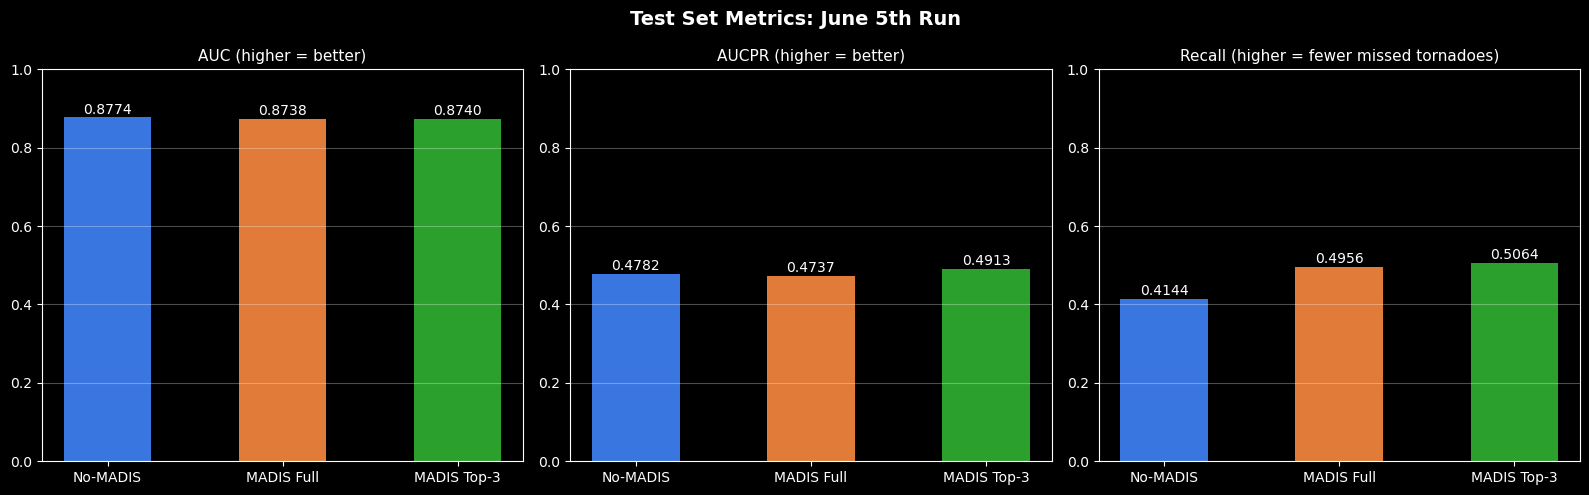

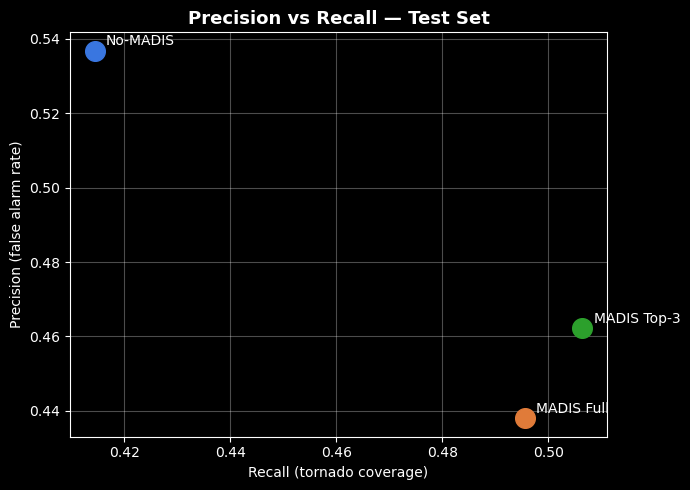

In [9]:
test_results = {
    'No-MADIS': {
        'AUC': 0.8774, 'AUCPR': 0.4782, 'F1': 0.4677,
        'Precision': 0.5368, 'Recall': 0.4144, 'BinaryAccuracy': 0.9403,
    },
    'MADIS Full': {
        'AUC': 0.8738, 'AUCPR': 0.4737, 'F1': 0.4650,
        'Precision': 0.4380, 'Recall': 0.4956, 'BinaryAccuracy': 0.9332,
    },
    'MADIS Top-3': {
        'AUC': 0.8740, 'AUCPR': 0.4913, 'F1': 0.4833,
        'Precision': 0.4622, 'Recall': 0.5064, 'BinaryAccuracy': 0.9365,
    },
}

test_df = pd.DataFrame(test_results).T
print("=== Test Set Results ===")
print(test_df.round(4))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = [
    ('AUC',    'AUC (higher = better)'),
    ('AUCPR',  'AUCPR (higher = better)'),
    ('Recall', 'Recall (higher = fewer missed tornadoes)'),
]
colors = ['#3976e0', '#e07b39', '#2ca02c']

for ax, (metric, title) in zip(axes, metrics_to_plot):
    vals = [test_results[m][metric] for m in test_results]
    bars = ax.bar(test_results.keys(), vals, color=colors, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Test Set Metrics: June 5th Run', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/june5_test_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision vs Recall
fig, ax = plt.subplots(figsize=(7, 5))
for model, color in zip(test_results, colors):
    ax.scatter(test_results[model]['Recall'], test_results[model]['Precision'],
               s=200, color=color, label=model, zorder=5)
    ax.annotate(model, (test_results[model]['Recall'], test_results[model]['Precision']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)
ax.set_xlabel('Recall (tornado coverage)')
ax.set_ylabel('Precision (false alarm rate)')
ax.set_title('Precision vs Recall — Test Set', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/june5_test_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Test Set Results (Held-Out)

Scores from running `test_tornado_keras.py` on the full TorNet test split.

## Next Steps

1. **Evaluate on 2022 test set** — run `test_tornado_keras.py` on all three best checkpoints to get final unbiased metrics.

2. **Revisit MADIS top-3 feature selection** — pressure_anomaly_24h, wind_anomaly_24h, and the instability proxies may be more discriminative than the raw readings (pressure, wind_gust). Re-run ablation with anomaly features only.

3. **Examine MADIS sample coverage** — MADIS-eligible runs train on a filtered subset of TorNet. Quantify how many training samples were dropped and whether coverage is uniform across tornado/non-tornado classes.

4. **Longer training with cosine annealing** — both MADIS models hit peak early and then plateau. A learning rate schedule with restarts might help escape the plateau.